# Introduction

This notebook demonstrates an example workflow for the ClearSAR Challenge. It includes:

- A description of the dataset and label format (COCO-style bounding boxes).
- A minimal training loop showing how to fine-tune a Faster R-CNN detector on the training set.
- How to generate detections on the test set and generate a valid submission JSON file.
- How to evaluate results locally on the subset of the training set using COCO tools.

In [ ]:
import json
import itertools
import random
from pathlib import Path
from typing import Callable, Any

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Data download

To get the dataset instantly, please follow this link: https://www.eotdl.com/datasets/ClearSAR

From there you can stage the dataset directly using the following CLI command:

In [ ]:
!pip install eotdl
!eotdl datasets get ClearSAR

If you need further support on how to stage a dataset from EOTDL, please refer to the tutorial notebook provided here: https://www.eotdl.com/docs/datasets/stage

# Data description

The dataset consists of Sentinel-1 quick-look images (RGB PNGs) annotated with RFI locations.
Annotations are stored in COCO-style JSON files where each annotation contains a bounding box in COCO format [x, y, w, h].

- Images: small Sentinel-1 quick-look PNGs.
- Labels: COCO `instances_*.json` containing `images`, `annotations`, and `categories` sections.

Throughout this notebook COCO boxes are transformed to the format expected by torchvision models where necessary.

In [ ]:
# Define dataset and model paths.
data_dir = Path("data")
train_dir = data_dir / "images/train"
test_dir = data_dir / "images/test"
model_dir = Path("models")
out_dir = Path("submission.json")
train_labels_path = data_dir / "annotations/instances_train.json"

# Training configuration: simple defaults used for the example run.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 3
num_iter = 20
batch_size = 8

# Random seed for reproducibility of experiments
seed = 0

In [ ]:
# Set random seed to make training deterministic
# Note: full determinism in CUDA can still be difficult to guarantee.
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Data visualization

Visualize example training samples with their RFIs as red bounding boxes.

In [ ]:
def show_image_with_boxes(image: Image.Image, boxes: list[list[float]]):
    """
    Display an image with bounding boxes overlaid.

    This function visualizes an image with rectangular bounding boxes drawn on top.

    Args:
        image (PIL.Image.Image): The image to display.
        boxes (list[list[float]]): List of bounding boxes in COCO format [x, y, w, h],
                                   where (x, y) is the top-left corner and (w, h) are width and height.
    """
    # Create a single subplot and show the image
    fig, ax = plt.subplots(1)
    ax.imshow(image)

    # Draw each bounding box as a red rectangle
    for box in boxes:
        x, y, w, h = box
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

    # Hide axis ticks/labels for a cleaner visualization
    plt.axis('off')
    plt.show()

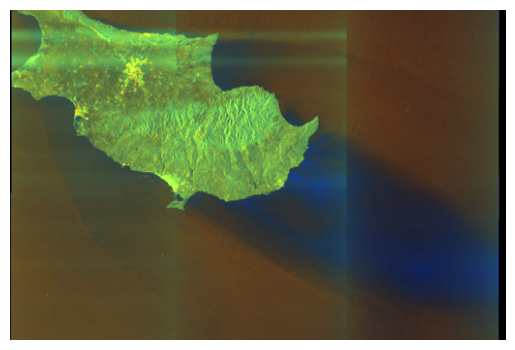

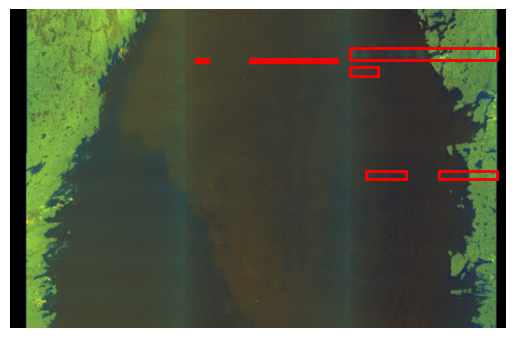

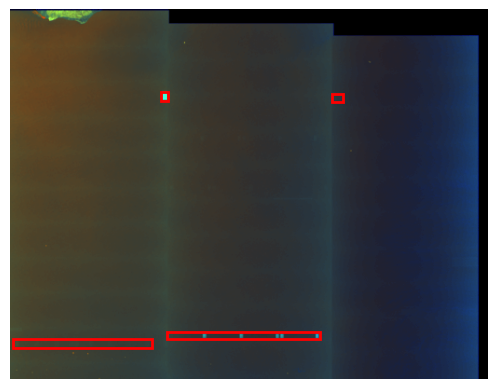

In [ ]:
sample_img_ids = [10, 90, 356]
with open(train_labels_path) as f:
    gt = json.load(f)
annot = gt["annotations"]

for sample_img_id in sample_img_ids:
    sample_img_path = train_dir / f"{sample_img_id}.png"
    sample_img_bboxes = [ann["bbox"] for ann in annot if ann["image_id"] == sample_img_id]
    sample_img = Image.open(sample_img_path)
    show_image_with_boxes(sample_img, sample_img_bboxes)

# Data processing

Convert COCO-style [x, y, w, h] boxes to `torchvision` [x_min, y_min, x_max, y_max] and prepare target dictionaries with 'boxes' and 'labels' tensors.

In [ ]:
targets_list = []
train_list = []
for img_fname in train_dir.iterdir():
    img_id = int(img_fname.stem)
    boxes = [a["bbox"] for a in annot if a["image_id"] == img_id]
    if boxes == []:
        # Skip images without annotations (no RFIs)
        continue
    train_list.append(img_fname)
    for i, bbox in enumerate(boxes):
        x_min, y_min, w, h = bbox
        x_max = x_min + w
        y_max = y_min + h
        boxes[i] = [x_min, y_min, x_max, y_max]
    targets_list.append({
        "boxes": torch.tensor(boxes, dtype=torch.float32),
        "labels": torch.tensor([1] * len(boxes), dtype=torch.int64)
    })

assert len(train_list) == len(targets_list)  # Sanity check: one target per image

`torch` `Dataset` wrapper used by the `DataLoader` during training and evaluation

In [ ]:
class RFIDataset(Dataset):
    """
    PyTorch Dataset for loading RFI (Radio Frequency Interference) detection images and their annotations.

    This dataset class handles loading images and their corresponding bounding box annotations,
    with optional image transformations.
    """

    def __init__(
            self,
            images: list[Path],
            targets: list[dict[str, torch.Tensor]] | None=None,
            transforms: Callable[[Any], Any] | None=None
        ):
        """
        Initialize the RFIDataset.

        Args:
            images (list): List of image file paths to load.
            targets (list, optional): List of target dictionaries containing 'boxes' and 'labels' tensors.
                                     If None, the dataset operates in inference mode. Defaults to None.
            transforms (callable, optional): Optional image transformation function to apply. Defaults to None.
        """
        self.images = images
        self.targets = targets
        self.transforms = transforms

    def __getitem__(self, idx: int) -> tuple[Image.Image | torch.Tensor, dict | None, Path]:
        """
        Get an image, its target annotations, and file path by index.

        Args:
            idx (int): Index of the sample to retrieve.

        Returns:
            tuple: A tuple containing:
                - img (PIL.Image or Tensor): The image, optionally transformed.
                - target (dict or None): Dictionary with 'boxes' and 'labels' tensors, or None if targets not provided.
                - img_path (Path): Path to the image file.
        """
        img = Image.open(self.images[idx])
        target = self.targets[idx] if self.targets is not None else None
        if self.transforms:
            img = self.transforms(img)
        return img, target, self.images[idx]

    def __len__(self) -> int:
        """
        Get the total number of samples in the dataset.

        Returns:
            int: Number of images in the dataset.
        """
        return len(self.images)

Build dataset and `DataLoader`. The custom `collate_fn` unpacks tuples produced by the dataset.

In [ ]:
train_data = RFIDataset(train_list, targets_list, transforms=T.ToTensor())
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Training

This is a short example training loop for demonstration purposes.

In [ ]:
model = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights="DEFAULT")
model.to(device)
model.train()

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
for epoch in range(num_epochs):
    print(f"Starting epoch {epoch+1}")
    # Only iterate a limited number of batches (num_iter) to keep example runs fast
    for imgs, targets, _ in tqdm(itertools.islice(train_loader, num_iter), total=num_iter):
        imgs = list(img.to(device) for img in imgs)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        # Forward pass (model returns loss dict when in training mode)
        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())

        # Backpropagation step
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} done, loss={losses.item():.4f}")
model_dir.mkdir(exist_ok=True)
# Save model weights for later use.
torch.save(model.state_dict(), model_dir / "model.pth")

Starting epoch 1


100%|██████████| 20/20 [03:05<00:00,  9.26s/it]


Epoch 1 done, loss=0.2952
Starting epoch 2


100%|██████████| 20/20 [03:11<00:00,  9.56s/it]


Epoch 2 done, loss=0.4097
Starting epoch 3


100%|██████████| 20/20 [03:21<00:00, 10.08s/it]


Epoch 3 done, loss=0.5816


# Testing

Run inference on the test set and collect detections in COCO-style format.

In [ ]:
test_list = list(test_dir.iterdir())
test_data = RFIDataset(test_list, None, transforms=T.ToTensor())
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

In [ ]:
model.eval()
detections = []
for i, (imgs, _, img_paths) in tqdm(enumerate(test_loader), total=len(test_loader)):
    imgs = list(img.to(device) for img in imgs)
    with torch.no_grad():
        outputs = model(imgs)
    # `outputs` is a list of dicts (one per input image) containing 'boxes', 'labels' and 'scores'
    for output, img_path in zip(outputs, img_paths):
        boxes = output['boxes'].cpu()
        scores = output['scores'].cpu()
        for box, score in zip(boxes, scores):
            x_min, y_min, x_max, y_max = box
            # Convert to COCO [x, y, w, h] format
            box = [x_min, y_min, x_max - x_min, y_max - y_min]
            detections.append({
                "image_id": int(img_path.stem),
                "category_id": 1,
                "bbox": list(map(float, box)),
                "score": float(score)
            })

100%|██████████| 99/99 [06:45<00:00,  4.10s/it]


Save detections to a JSON file in the format expected by the competition submission (https://platform-challenges.philab.esa.int/clear-sar/submissions).

In [ ]:
with open(out_dir, "w") as f:
    json.dump(detections, f)

Visualize sample test data

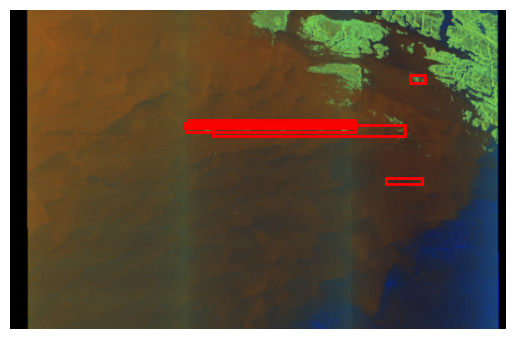

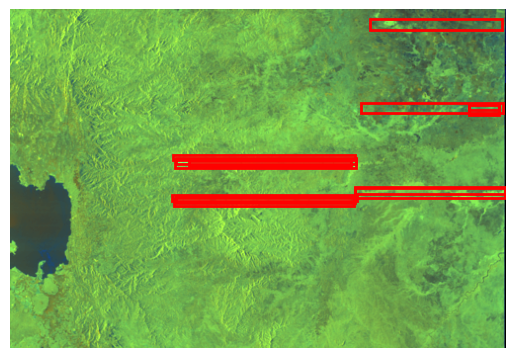

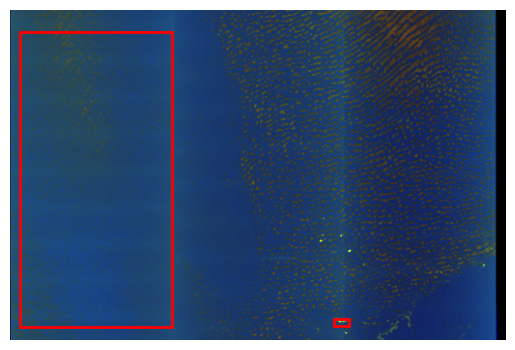

In [ ]:
sample_img_ids = [10, 90, 356]
threshold = 0.3

for sample_img_id in sample_img_ids:
    sample_img_path = test_dir / f"{sample_img_id}.png"
    sample_img_bboxes = [det["bbox"] for det in detections if det["image_id"] == sample_img_id and det["score"] >= threshold]
    sample_img = Image.open(sample_img_path)
    show_image_with_boxes(sample_img, sample_img_bboxes)

Evaluate using COCO tools on a small sample of training images.

In [ ]:
model.eval()
detections_sample = []
img_ids_sample = []
for i, (imgs, _, img_paths) in tqdm(enumerate(itertools.islice(train_loader, 3)), total=3):
    imgs = list(img.to(device) for img in imgs)
    with torch.no_grad():
        outputs = model(imgs)
    for output, img_path in zip(outputs, img_paths):
        img_ids_sample.append(int(img_path.stem))
        boxes = output['boxes'].cpu()
        scores = output['scores'].cpu()
        for box, score in zip(boxes, scores):
            x_min, y_min, x_max, y_max = box
            box = [x_min, y_min, x_max - x_min, y_max - y_min]
            detections_sample.append({
                "image_id": int(img_path.stem),
                "category_id": 1,
                "bbox": list(map(float, box)),
                "score": float(score)
            })

100%|██████████| 3/3 [00:12<00:00,  4.22s/it]


In [ ]:
coco_gt = COCO(train_labels_path)
coco_dt = coco_gt.loadRes(detections_sample)
evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
evaluator.params.imgIds = img_ids_sample
evaluator.evaluate()
evaluator.accumulate()
evaluator.summarize()
print("mAP metric:", float(evaluator.stats[0]))

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.105
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.291
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.062
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.026
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.196
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.068
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.100
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.263
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets